# Analyzing EPIC 4 outputs

In [1]:
from epicpy import EPIC_Extractor
import matplotlib.pyplot as plt
import pprint

## Loading the extractor object
`EPIC_Extractor` is the base class to load outputs from EPIC 4. The input arguments to create the extractor is the path to the folder containing the `extract***.nc` files. 

In [2]:
extractor = EPIC_Extractor("../tests/epic4_test/")

If the run has additional simulations that are restarted from an output, we can add them using `extractor.add_restarts(...)` where the input argument is the path to the folder with the restarted `extract***.nc`. 


---
**NOTE:**

The restarts are always added to the end of the list (i.e., assuming that the last output in the list of outputs loaded is the same as the first output from the new restarts added). This behavious can be changed by setting the `start` argument (default: `-1`, i.e., start with the last output) which points to the index of the current list where the restarts should be appended.

---

In [3]:
extractor.add_restarts("../tests/epic4_test/restart1/")

Let's print out the output times loaded from the model. By default `time` is in days from the initialization of the model, so here, we can print it in seconds:

In [4]:
extractor.time * 86400  # to seconds

array([    0.,  1500.,  3000.,  4500.,  6000.,  7500.,  9000., 10500.,
       12000., 13500., 15000., 16500., 18000., 19500., 21000., 22500.,
       24000., 25500., 27000., 28500., 30000.])

## Fetching output attributes
The netCDF outputs contain various attributes describing the model, the specific run and also properties of the atmosphere. These can be retrieved using the `get_attrs()` method which takes two inputs:
- `time`: the index of the output
- `attrs`: either a list of attribute keys or a single attribute key or `None`. If left as `None`, the function will return all attributes
The output is produced as a dictionary of `{key: value}` pairs where each key corresponds to an individual attribute from the input

In [5]:
extractor.get_attrs(0, "planet_name")

{'planet_name': 'jupiter'}

`attrs` can also accept glob style keywords, which fetches all attributes that match the pattern

In [6]:
pprint.pprint(extractor.get_attrs(0, "planet_*"))

{'planet_GM': np.float64(1.266865e+17),
 'planet_J2': np.float64(0.014697),
 'planet_a': np.float64(5.20336301),
 'planet_cp': np.float64(9092.5),
 'planet_dynvisc': np.float64(3e-06),
 'planet_e': np.float64(0.04839266),
 'planet_i': np.float64(1.3053),
 'planet_index': np.int32(1),
 'planet_k_a': np.float64(0.2),
 'planet_kinvisc': np.float64(0.000101),
 'planet_lon_ascending_node': np.float64(100.55615),
 'planet_lon_perihelion': np.float64(14.75385),
 'planet_mean_lon': np.float64(34.40438),
 'planet_name': 'jupiter',
 'planet_obliquity': np.float64(3.12),
 'planet_omega_sidereal': np.float64(0.00017585),
 'planet_omega_synodic': np.float64(0.00017584),
 'planet_orbit_period': np.float64(11.8623),
 'planet_orbital_epoch': 'J2000',
 'planet_re': np.float64(71492000.0),
 'planet_rgas': np.float64(3637.0),
 'planet_rp': np.float64(66852000.0),
 'planet_type': 'gas-giant',
 'planet_vernal_equinox_anomaly': np.float64(302.592),
 'planet_x_3': np.float64(0.0),
 'planet_x_h2': np.float64(

## Model coordinates
The model coordinates are automatically extracted for easy use. EPIC uses the Arakawa C-grid, so velocities are stored in the faces, while the mass variables (pressure, density, mixing ratios, potential temperature, etc.) as stored in the cell center. Vorticity (and PV) are stored on the cell edges. Therefore, there are four sets of coordinates for each dimension (`lon`, `lat`, `sigmatheta`):
- `lon_h`, `lat_h`, `sigmatheta_h`: are the cell centered values of longitude, latitude and $\sigma-\theta$
- `lon_u`, `lat_u`, `sigmatheta_u`: are the east-west face values of longitude, latitude and $\sigma-\theta$, corresponding to the zonal velocities
- `lon_v`, `lat_v`, `sigmatheta_v`: are the north-south face values of longitude, latitude and $\sigma-\theta$ corresponding to the meridional velocities
- `lon_pv`, `lat_pv`, `sigmatheta_pv`: are the cell edge values of longitude, latitude and $\sigma-\theta$ corresponding to the vorticity variables

In [7]:
# This is a 1D (column) simulation, so there are only one value for each
print(f"Mass centered longitude: {extractor.lon_h} and latitude: {extractor.lat_h}")
print(f"East-west face longitude: {extractor.lon_u} and latitude: {extractor.lat_u}")
print(f"North-south face longitude: {extractor.lon_v} and latitude: {extractor.lat_v}")
print(f"Cell edge longitude: {extractor.lon_pv} and latitude: {extractor.lat_pv}")

Mass centered longitude: [0.] and latitude: [0.]
East-west face longitude: [-10.] and latitude: [0.]
North-south face longitude: [0.] and latitude: [-10.]
Cell edge longitude: [-10.] and latitude: [-10.]


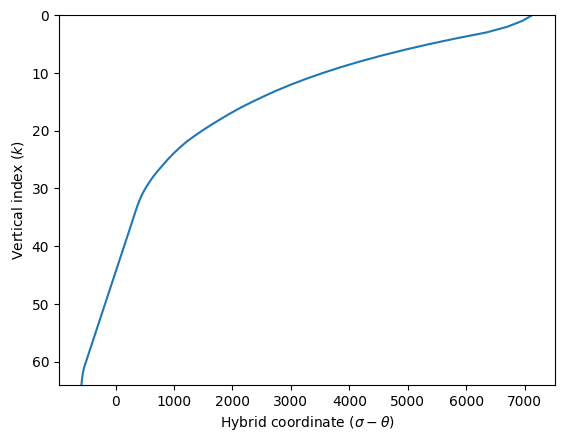

In [8]:
fig, ax = plt.subplots(1, 1, dpi=100)
ax.plot(extractor.sigmatheta, range(extractor.grid_nk + 1))
ax.set_ylim((extractor.grid_nk, 0))
ax.set_xlabel(rf'Hybrid coordinate ($\sigma-\theta$)')
ax.set_ylabel('Vertical index ($k$)')
plt.show()

## Interfacing directly with an output file

The `open_file()` method can be used to return a pointer to the the netCDF `Dataset` class. This is useful when needing to access data from the file directly. For example, we can use it to get a list of variables and specific information about each variable:

In [9]:
with extractor.open_file(0) as dset:
    for variable in dset.variables.keys():
        var = dset.variables[variable]
        print(f"{variable:>20s}: {var.getncattr('long_name')} [{var.getncattr("units")}]")

                time: elapsed time [days since 1902-01-01 00:00:00 0]
                 L_s: solar longitude (planetocentric) [degrees]
               lon_u: longitude [degrees_east]
               lat_u: latitude (planetographic) [degrees_north]
        sigmatheta_u: hybrid sigma-theta vertical coordinate [K]
               lon_v: longitude [degrees_east]
               lat_v: latitude (planetographic) [degrees_north]
        sigmatheta_v: hybrid sigma-theta vertical coordinate [K]
               lon_h: longitude [degrees_east]
               lat_h: latitude (planetographic) [degrees_north]
        sigmatheta_h: hybrid sigma-theta vertical coordinate [K]
              lon_pv: longitude [degrees_east]
              lat_pv: latitude (planetographic) [degrees_north]
       sigmatheta_pv: hybrid sigma-theta vertical coordinate [K]
              lon_h2: longitude [degrees_east]
              lat_h2: latitude (planetographic) [degrees_north]
       sigmatheta_h2: hybrid sigma-theta vertical 

## Fetching variables from an output

Output variables can be retrieved with the `get_variable` method as shown below. This method takes the variable name and the time index to retrieve it from. If there is no time index, the function concatenates the variable output from all the output timesteps and returns a corresponding multidimensional array.

Here, we are using it to extract the vapor mass mixing ratios from the last output. Note that to plot the curves

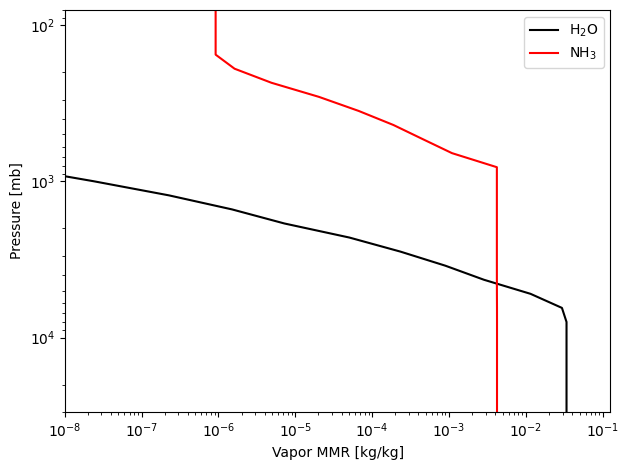

In [10]:
# vapor variables are [pressure, latitude, longitude]. This is a 1D simulation so we just need the column
H2Ovapor = extractor.get_variable('H_2O_vapor', -1)[:, 0, 0]

# this is also possible if we want to extract all the timesteps for analysis, but we just want to plot the last output in this script
NH3vapor = extractor.get_variable('NH_3_vapor')[-1, :, 0, 0]

# get the pressure (which is not a vertical coordinate in EPIC4)
p = extractor.get_variable('p', -1)[:, 0, 0]

fig, ax = plt.subplots(1, 1, dpi=100)
ax.plot(H2Ovapor, p / 100, 'k-', label=r'H$_2$O')
ax.plot(NH3vapor, p / 100, 'r-', label=r'NH$_3$')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim((30000, 80))
ax.set_xlim(left=1e-8)
ax.set_xlabel(r'Vapor MMR [kg/kg]')
ax.set_ylabel(r'Pressure [mb]')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

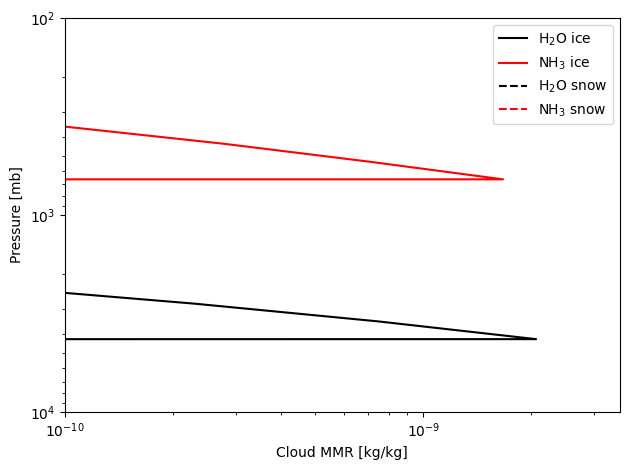

In [11]:
# let's use the same technique to plot the cloud mixing ratios

H2Osolid = extractor.get_variable('H_2O_solid', -1)[:, 0, 0]  # get from the last output
NH3solid = extractor.get_variable('NH_3_solid', -1)[:, 0, 0]  # get from the last output

H2Osnow = extractor.get_variable('H_2O_snow', -1)[:, 0, 0]  # get from the last output
NH3snow = extractor.get_variable('NH_3_snow', -1)[:, 0, 0]  # get from the last output

# get the pressure (which is not a vertical coordinate in EPIC4)
p = extractor.get_variable('p', -1)[:, 0, 0]

fig, ax = plt.subplots(1, 1, dpi=100)
ax.plot(H2Osolid, p / 100, 'k-', label=r'H$_2$O ice')
ax.plot(NH3solid, p / 100, 'r-', label=r'NH$_3$ ice')

ax.plot(H2Osnow, p / 100, 'k--', label=r'H$_2$O snow')
ax.plot(NH3snow, p / 100, 'r--', label=r'NH$_3$ snow')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim((10000, 100))
ax.set_xlim(left=1e-10)
ax.set_xlabel(r'Cloud MMR [kg/kg]')
ax.set_ylabel(r'Pressure [mb]')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()